In [1]:

import os
import math
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

from tqdm.auto import tqdm

def set_seed(seed: int = 0):
    torch.manual_seed(seed)
    np.random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def show_grid(images, title="", ncols=8, figsize=(18, 6), vmin=0.0, vmax=1.0):
    """
    images: list of 2D numpy arrays in [0,1]
    """
    n = len(images)
    ncols = min(ncols, n)
    nrows = int(math.ceil(n / ncols))
    plt.figure(figsize=figsize)
    for i, img in enumerate(images):
        ax = plt.subplot(nrows, ncols, i + 1)
        ax.imshow(img, vmin=vmin, vmax=vmax, cmap="gray")
        ax.axis("off")
        ax.set_title(str(i))
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

def plot_series(x, y, title="", xlabel="", ylabel=""):
    plt.figure(figsize=(10, 4))
    plt.plot(x, y)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

/export/livia/home/vision/Fbassignana/miniconda3/envs/diffusers-dev/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# -----------------------------
# REQUIRED: update these paths
# -----------------------------
PIPELINE_DIR = "./serious_runs/stable_training_no_norm_longrun"  # contains VAE/ and UNET/
SURPRISE_CKPT = "./runs/surprise_predictor_longer_run/vae_x4_best_minmax_h256_s0/best_model.pt"  # optional (needed for non-euler)

# Optional override (if you want to load VAE weights explicitly on top of auto-load)
VAE_WEIGHTS_OVERRIDE = None  # e.g. "./serious_runs/stable_training_no_norm/VAE/vae_best.pt"

# Device
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# Sampling parameters
N_STEPS = 50
BATCH_SIZE = 1   # keep 1 for visualization
T_SCALE = 1000.0

# Visualization / logging frequency
STORE_EVERY = 1           # store every k steps
SCORE_EVERY = 5           # compute surprise/gmm every k steps (set None to disable)
SEED = 0

# Guidance parameters (used by guided methods)

In [3]:
# Make sure repo imports work
import sys
sys.path.insert(0, os.path.abspath("."))

from fm_src.pipelines.flow_matching_pipeline import StableFlowMatchingPipeline

set_seed(SEED)

pipe = StableFlowMatchingPipeline(
    device=DEVICE,
    t_scale=T_SCALE,
    model_dir=PIPELINE_DIR,
)

pipe.load_from_pipeline_folder_auto(
    PIPELINE_DIR,
    strict=True,
    map_location=DEVICE,
    set_eval=True,
)

if VAE_WEIGHTS_OVERRIDE is not None:
    print(f"[override] loading VAE weights: {VAE_WEIGHTS_OVERRIDE}")
    pipe.load_vae_weights(VAE_WEIGHTS_OVERRIDE, strict=True, map_location=DEVICE)
    pipe.vae.eval()

pipe.freeze_vae()

print("Loaded pipeline OK.")
print("Device:", DEVICE)
print("UNet train_target:", pipe.train_target)
print("Sample shape:", pipe._get_unet_sample_shape())

/export/livia/home/vision/Fbassignana/miniconda3/envs/diffusers-dev/lib/python3.10/site-packages/generative/networks/layers/vector_quantizer.py:86: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  @torch.cuda.amp.autocast(enabled=False)
/export/livia/home/vision/Fbassignana/miniconda3/envs/diffusers-dev/lib/python3.10/site-packages/generative/networks/layers/vector_quantizer.py:124: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  @torch.cuda.amp.autocast(enabled=False)


Loaded pipeline OK.
Device: cuda
UNet train_target: v
Sample shape: (4, 64, 64)


In [66]:
from fm_src.guidance.score_predictor_guidance import ScoreGuidanceConfig, ScorePredictorGuidance

# ---- choose energy formula here ----
ENERGY_MODE = "combo"  # "surprise" | "gmm" | "combo"
SIGN = "maximize"         # "minimize" | "maximize"

W_SURPRISE = 2
W_GMM = -1   # if you want alpha*S - beta*(1-gmm), set this to -beta and ENERGY_MODE="combo"

LAMBDA_START = 1.5
LAMBDA_END = 1.5
LAMBDA_SCHEDULE = "cosine"  # constant | linear | cosine | step
GRAD_CLIP_NORM = 1
NORMALIZE_GRAD = False
GUIDANCE_ON = "latent"      # latent | decoded
USE_AMP = False
USE_DDIM_HAT = True         # Evaluate energy on DDIM clean estimate z_hat(z_t,t,v)
GUIDANCE_SCALE = 1.2      # multiplies g (which already includes λ(t))


guidance = None
if SURPRISE_CKPT is not None and os.path.isfile(SURPRISE_CKPT):
    cfg = ScoreGuidanceConfig(
        ckpt_path=SURPRISE_CKPT,
        energy_mode=ENERGY_MODE,
        sign=SIGN,
        w_surprise=W_SURPRISE,
        w_gmm=W_GMM,
        lambda_start=LAMBDA_START,
        lambda_end=LAMBDA_END,
        lambda_schedule=LAMBDA_SCHEDULE,
        grad_clip_norm=GRAD_CLIP_NORM,
        normalize_grad=NORMALIZE_GRAD,
        guidance_on=GUIDANCE_ON,
        use_ddim_hat=USE_DDIM_HAT,
        use_amp=USE_AMP,
    )
    guidance = ScorePredictorGuidance.from_checkpoint(cfg, device=DEVICE)
    print("Guidance loaded OK.  use_ddim_hat =", USE_DDIM_HAT)
else:
    print("Guidance not loaded (SURPRISE_CKPT missing). Only unguided euler will work.")

[ScorePredictorGuidance] Loading checkpoint: ./runs/surprise_predictor_longer_run/vae_x4_best_minmax_h256_s0/best_model.pt


Using cache found in /export/livia/home/vision/Fbassignana/.cache/torch/hub/facebookresearch_dinov2_main


[ScorePredictorGuidance] Ready.  energy_mode=combo  sign=maximize  guidance_on=latent  schedule=cosine
Guidance loaded OK.  use_ddim_hat = True


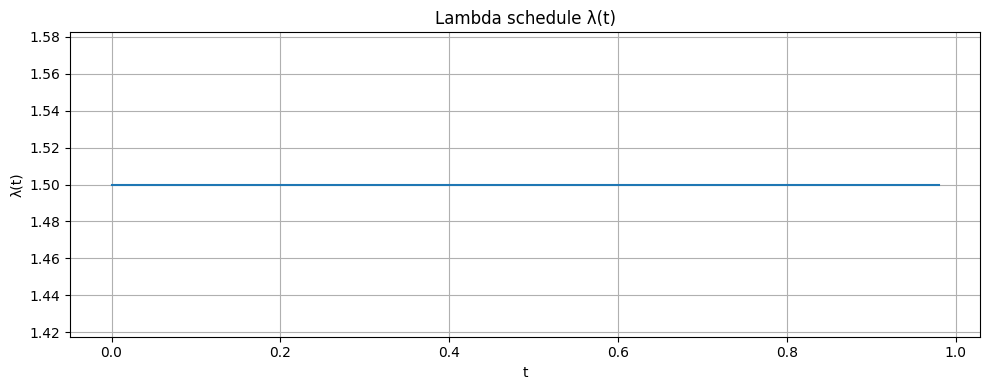

In [67]:
if guidance is None:
    print("No guidance loaded => skipping λ(t) plot.")
else:
    ts = [i / N_STEPS for i in range(N_STEPS)]
    lambdas = [guidance.compute_lambda(t) for t in ts]
    plot_series(ts, lambdas, title="Lambda schedule λ(t)", xlabel="t", ylabel="λ(t)")

In [68]:
@torch.no_grad()
def decode_to_vis(pipe, z):
    """
    z: (B,C,H,W) latent
    returns list of B images as 2D numpy arrays in [0,1]
    """
    x = pipe.decode_fm_output(z)               # (B,1,H,W) in [-1,1]
    x01 = ((x + 1.0) / 2.0).clamp(0, 1.0)      # (B,1,H,W) in [0,1]
    imgs = x01[:, 0].detach().cpu().numpy()    # list of (H,W)
    return list(imgs)

def run_euler_trajectory(
    pipe,
    steps: int,
    batch_size: int = 1,
    sample_shape=None,
    guidance=None,
    guidance_scale: float = 0.0,
    store_every: int = 1,
    score_every: int | None = None,
    collect_ddim_hat: bool = False,
):
    """
    Returns:
      frames: list of decoded images (for first sample in batch) in [0,1]
      logs: dict of lists (t, lambda, grad_norm, mean_surprise, mean_gmm)
      ddim_frames: list of decoded DDIM clean estimates (only when collect_ddim_hat=True)
    """
    assert hasattr(pipe, "unet")
    assert hasattr(pipe, "vae")
    pipe.unet.eval()
    pipe.vae.eval()

    shape = sample_shape or pipe._get_unet_sample_shape()
    z = torch.randn(batch_size, *shape, device=pipe.device)
    dt = 1.0 / steps

    frames = []
    ddim_frames = []
    logs = {
        "t": [],
        "lambda": [],
        "grad_norm": [],
        "mean_surprise": [],
        "mean_gmm": [],
    }

    for i in tqdm(range(steps), desc="trajectory"):
        t_val = i / steps
        t = torch.full((batch_size,), t_val, device=pipe.device)

        with torch.no_grad():
            unet_out = pipe.unet(z, t * pipe.t_scale).sample
            if pipe.train_target == "x0":
                t_exp = t[:, None, None, None]
                v = (unet_out - z) / (1.0 - t_exp).clamp(min=1e-5)
            else:
                v = unet_out

        g = None
        lam = 0.0
        gn = 0.0
        if guidance is not None and guidance_scale > 0.0:
            # Pass velocity so DDIM-hat guidance works when cfg.use_ddim_hat is True
            g = guidance.guidance_grad(z, t=t_val, pipeline=pipe, velocity=v)
            lam = guidance.compute_lambda(t_val)
            gn = g.view(batch_size, -1).norm(dim=1).mean().item()
            v = v + guidance_scale * g

        z = (z + v * dt).detach()

        if (i % store_every) == 0 or (i == steps - 1):
            imgs = decode_to_vis(pipe, z)
            frames.append(imgs[0])  # visualize first sample only

            # DDIM clean estimate: x_hat = z_t + (1-t) * v  (the model's prediction of clean data)
            if collect_ddim_hat:
                with torch.no_grad():
                    z_hat = z + (1.0 - t_val) * v.detach()
                ddim_imgs = decode_to_vis(pipe, z_hat)
                ddim_frames.append(ddim_imgs[0])

        # Logs
        logs["t"].append(t_val)
        logs["lambda"].append(lam)
        logs["grad_norm"].append(gn)

        if (score_every is not None) and (guidance is not None) and ((i % score_every) == 0 or (i == steps - 1)):
            # Evaluate scores on the DDIM-approximated z_1: z_hat = z + (1 - t) * v
            s = guidance.log_scores_DIMM(z_t=z, velocity=v, t=t_val)
            logs["mean_surprise"].append((i, s["mean_surprise"]))
            logs["mean_gmm"].append((i, s["mean_gmm"]))

    if collect_ddim_hat:
        return frames, logs, ddim_frames
    return frames, logs


trajectory:   0%|          | 0/2 [00:00<?, ?it/s]

trajectory: 100%|██████████| 2/2 [00:00<00:00,  7.43it/s]


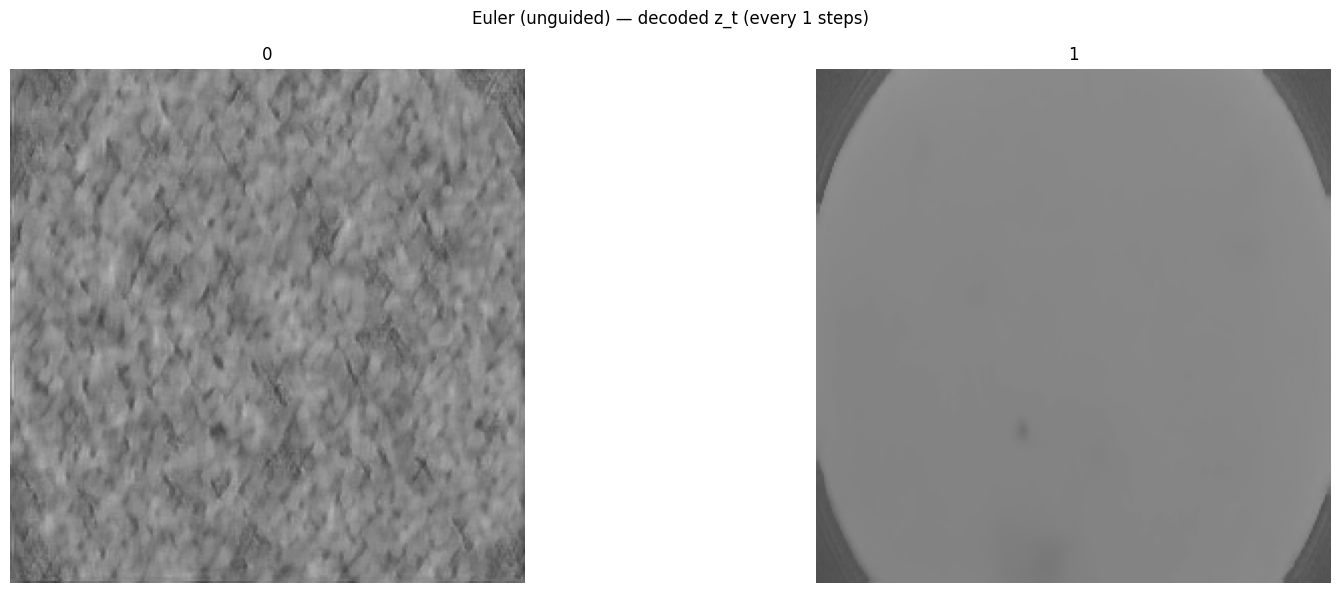

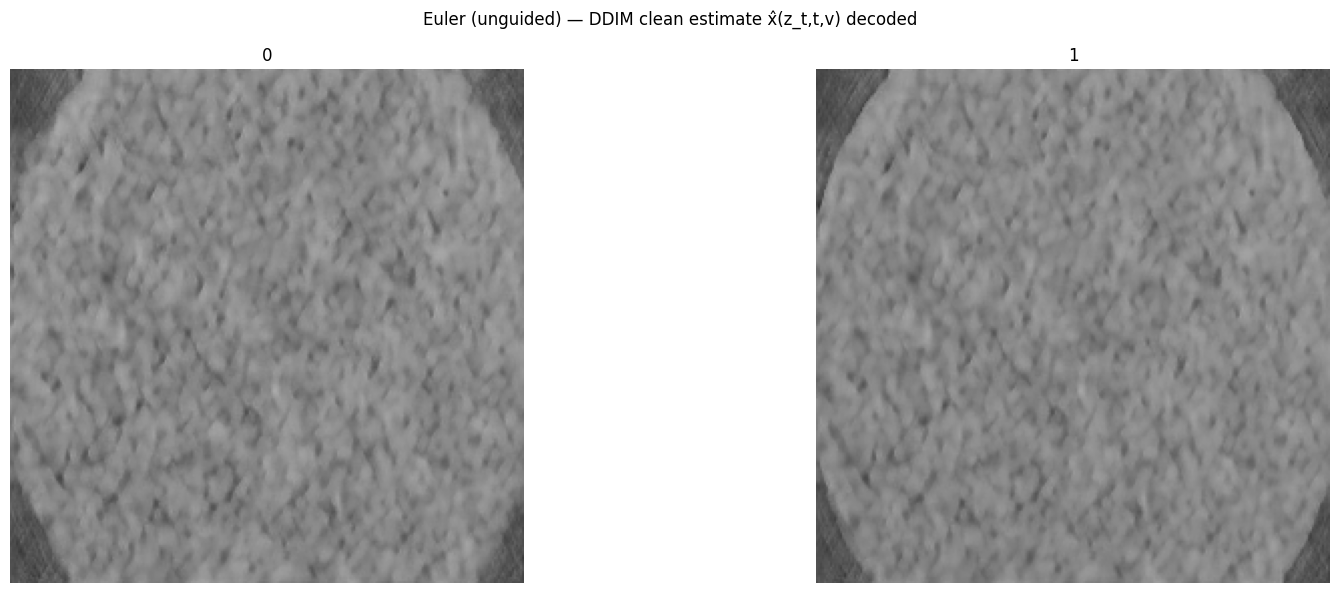

In [69]:
frames_euler, logs_euler, ddim_euler = run_euler_trajectory(
    pipe=pipe,
    steps=2,
    batch_size=BATCH_SIZE,
    guidance=None,
    guidance_scale=0.0,
    store_every=STORE_EVERY,
    score_every=None,
    collect_ddim_hat=True,
)

show_grid(frames_euler, title=f"Euler (unguided) — decoded z_t (every {STORE_EVERY} steps)")
show_grid(ddim_euler,   title=f"Euler (unguided) — DDIM clean estimate x̂(z_t,t,v) decoded")

trajectory:   0%|          | 0/50 [00:00<?, ?it/s]

[shape check]  z=[1, 4, 64, 64]  decoded=[1, 1, 256, 256]  dino_tokens=[1, 256, 384]  pooled=[1, 384]


trajectory: 100%|██████████| 50/50 [00:12<00:00,  4.08it/s]


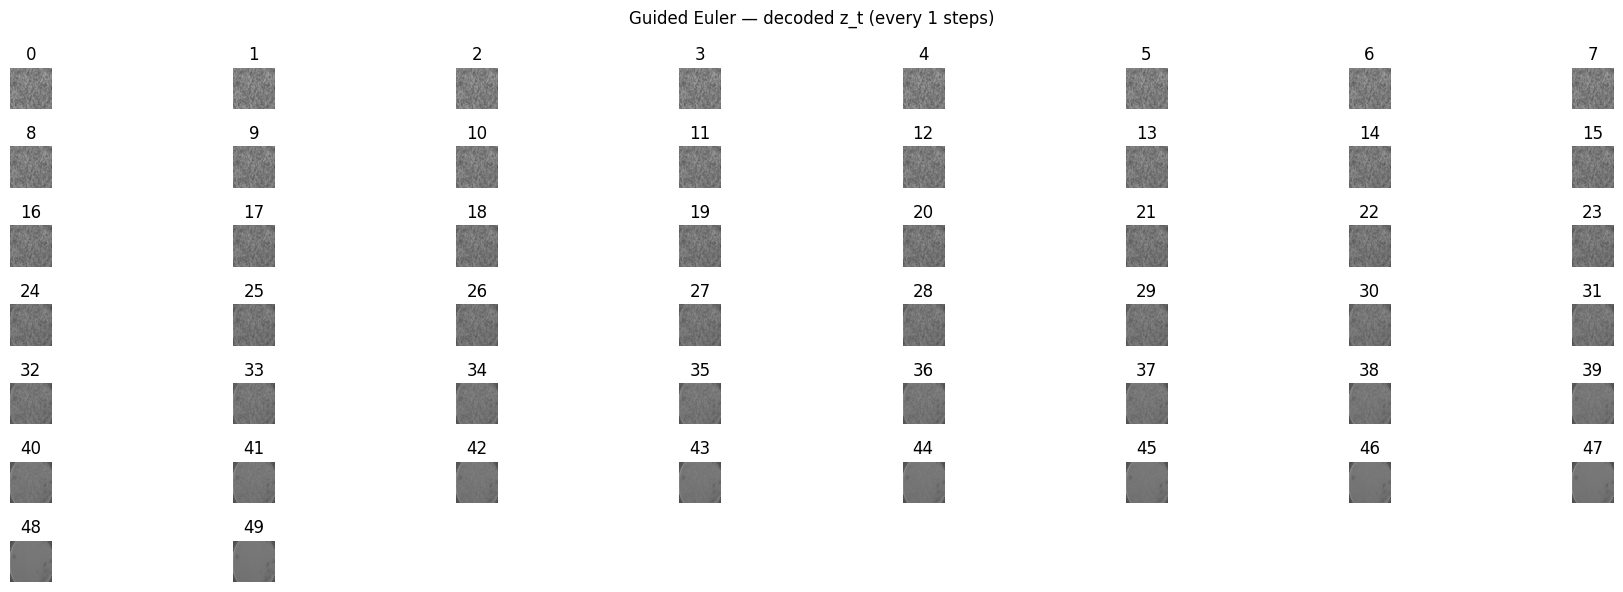

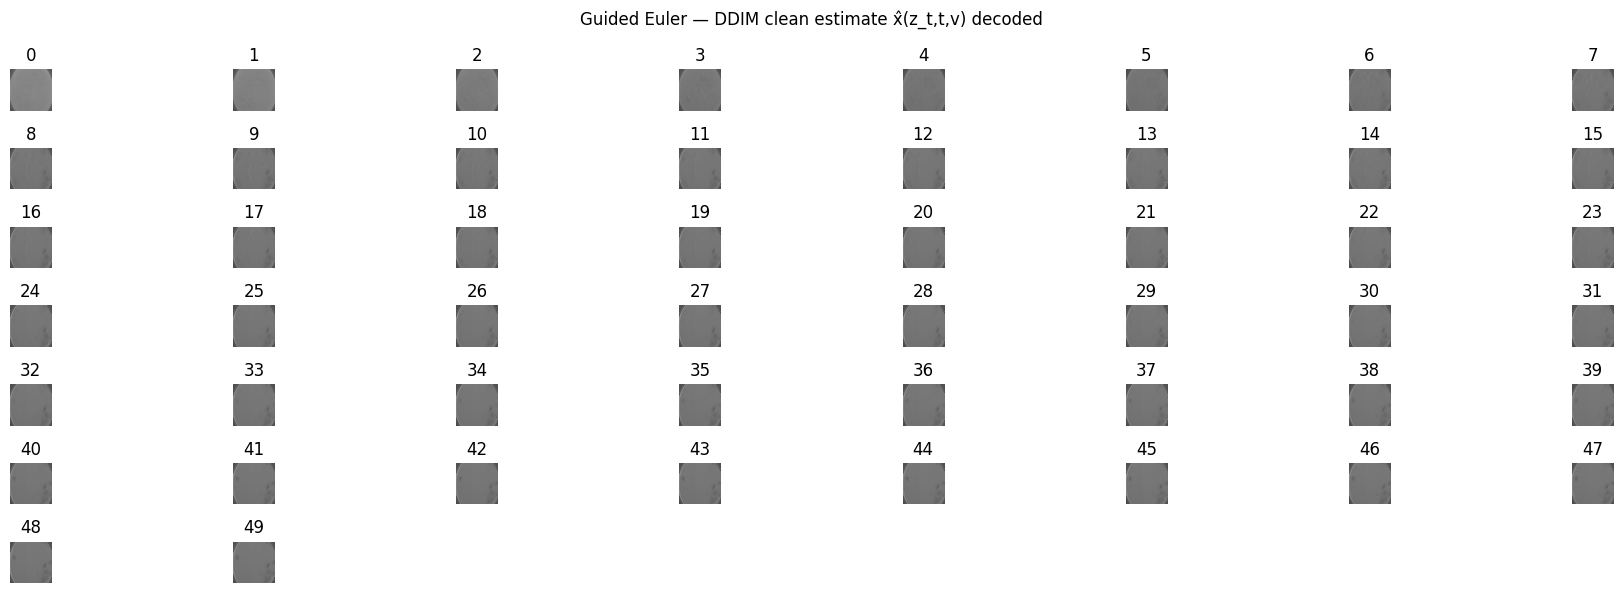

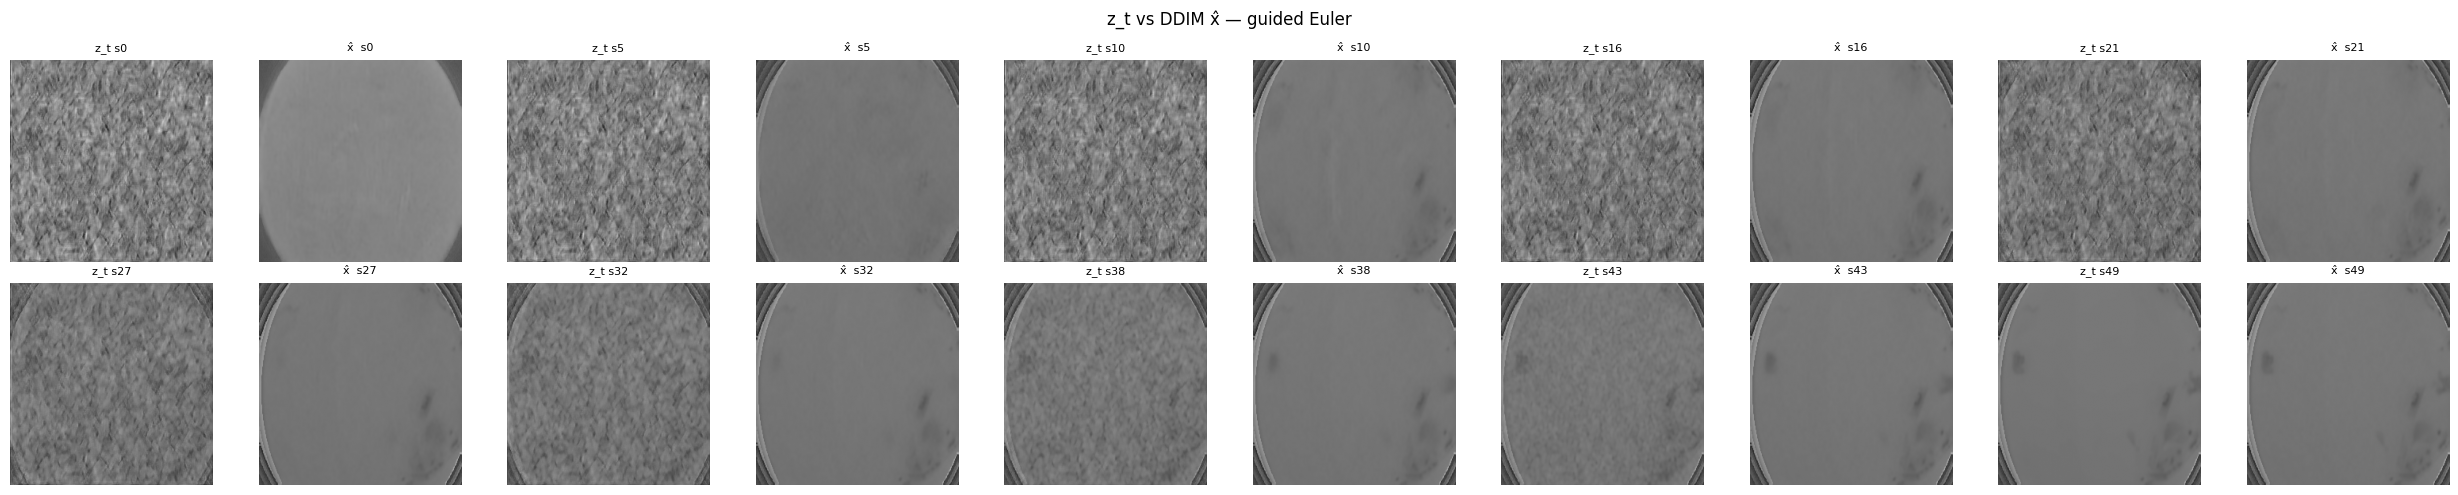

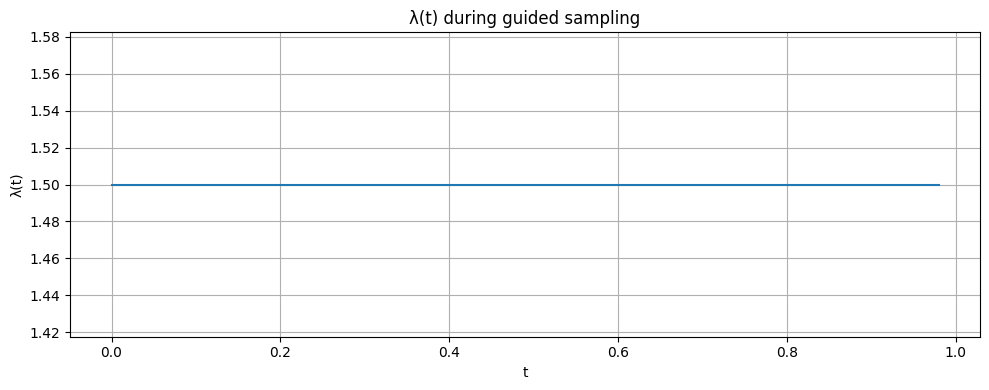

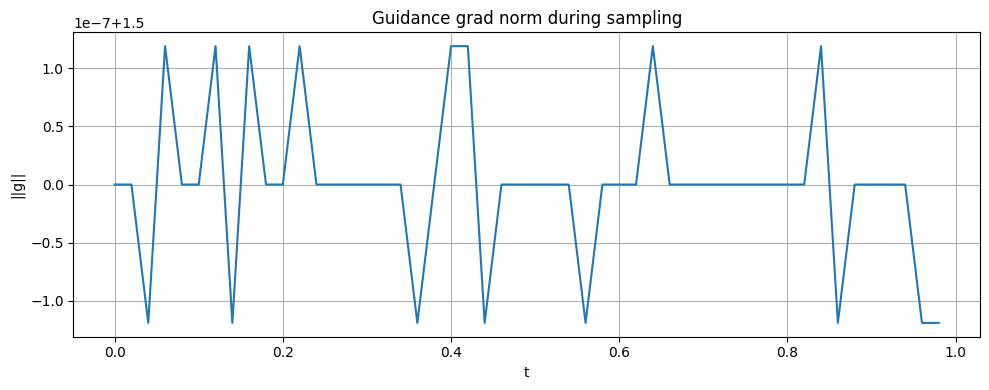

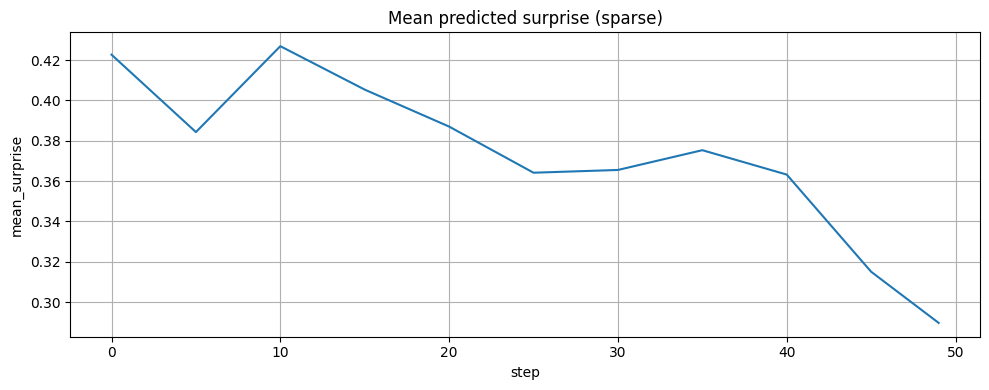

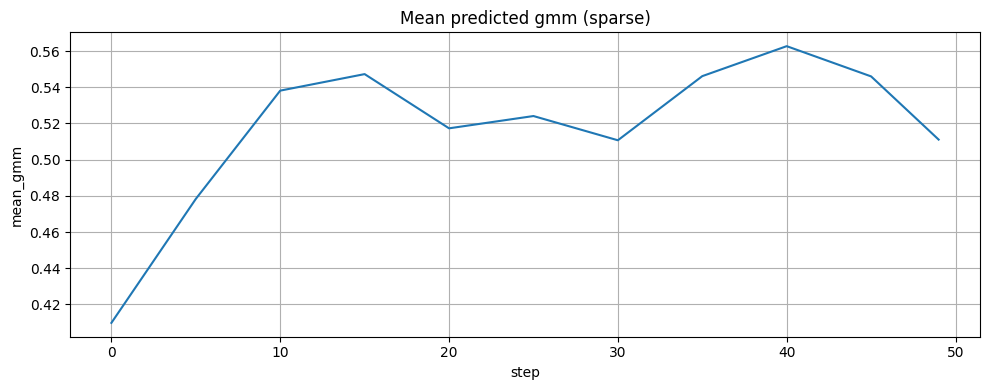

In [70]:
if guidance is None:
    print("No guidance => cannot run guided Euler.")
else:
    frames_guided, logs_guided, ddim_guided = run_euler_trajectory(
        pipe=pipe,
        steps=N_STEPS,
        batch_size=BATCH_SIZE,
        guidance=guidance,
        guidance_scale=GUIDANCE_SCALE,
        store_every=STORE_EVERY,
        score_every=SCORE_EVERY,
        collect_ddim_hat=True,
    
    )

    show_grid(frames_guided, title=f"Guided Euler — decoded z_t (every {STORE_EVERY} steps)")
    show_grid(ddim_guided,   title=f"Guided Euler — DDIM clean estimate x̂(z_t,t,v) decoded")

    # Side-by-side: interleave z_t and z_hat for direct comparison
    n_vis = min(len(frames_guided), 10)   # limit for readability
    step_idx = np.linspace(0, len(frames_guided) - 1, n_vis, dtype=int)
    interleaved = []
    row_labels = []
    for si in step_idx:
        interleaved.append(frames_guided[si])
        interleaved.append(ddim_guided[si])
        row_labels.extend([f"z_t s{si}", f"x̂  s{si}"])
    n_pairs = len(interleaved)
    ncols = min(n_pairs, 10)
    nrows = int(math.ceil(n_pairs / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(2.5 * ncols, 2.5 * nrows))
    axes = np.array(axes).flatten()
    for idx_ax in range(len(axes)):
        if idx_ax < n_pairs:
            axes[idx_ax].imshow(interleaved[idx_ax], vmin=0, vmax=1, cmap="gray")
            axes[idx_ax].set_title(row_labels[idx_ax], fontsize=8)
        axes[idx_ax].axis("off")
    fig.suptitle("z_t vs DDIM x̂ — guided Euler", fontsize=12)
    plt.tight_layout()
    plt.show()

    # Plot grad norm and λ(t)
    plot_series(logs_guided["t"], logs_guided["lambda"], title="λ(t) during guided sampling", xlabel="t", ylabel="λ(t)")
    plot_series(logs_guided["t"], logs_guided["grad_norm"], title="Guidance grad norm during sampling", xlabel="t", ylabel="||g||")

    if len(logs_guided["mean_surprise"]) > 0:
        xs = [a for (a, _) in logs_guided["mean_surprise"]]
        ys = [b for (_, b) in logs_guided["mean_surprise"]]
        plot_series(xs, ys, title="Mean predicted surprise (sparse)", xlabel="step", ylabel="mean_surprise")

    if len(logs_guided["mean_gmm"]) > 0:
        xs = [a for (a, _) in logs_guided["mean_gmm"]]
        ys = [b for (_, b) in logs_guided["mean_gmm"]]
        plot_series(xs, ys, title="Mean predicted gmm (sparse)", xlabel="step", ylabel="mean_gmm")

# Other

trajectory: 100%|██████████| 50/50 [00:04<00:00, 10.41it/s]


Candidate energies: [-0.08484005928039551, 1.0998921394348145, 1.412118911743164, 1.7494547367095947, 0.0021056532859802246, 1.4257566928863525, 1.4900174140930176, 0.8875815272331238]
Best candidate: 0 E= -0.08484005928039551


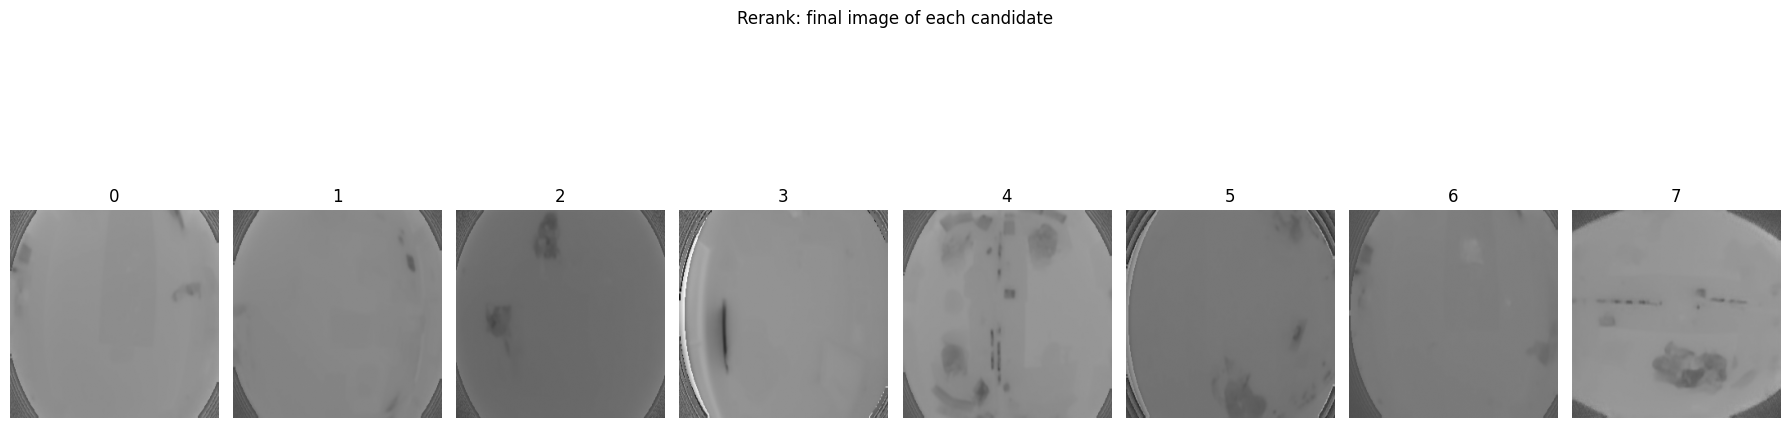

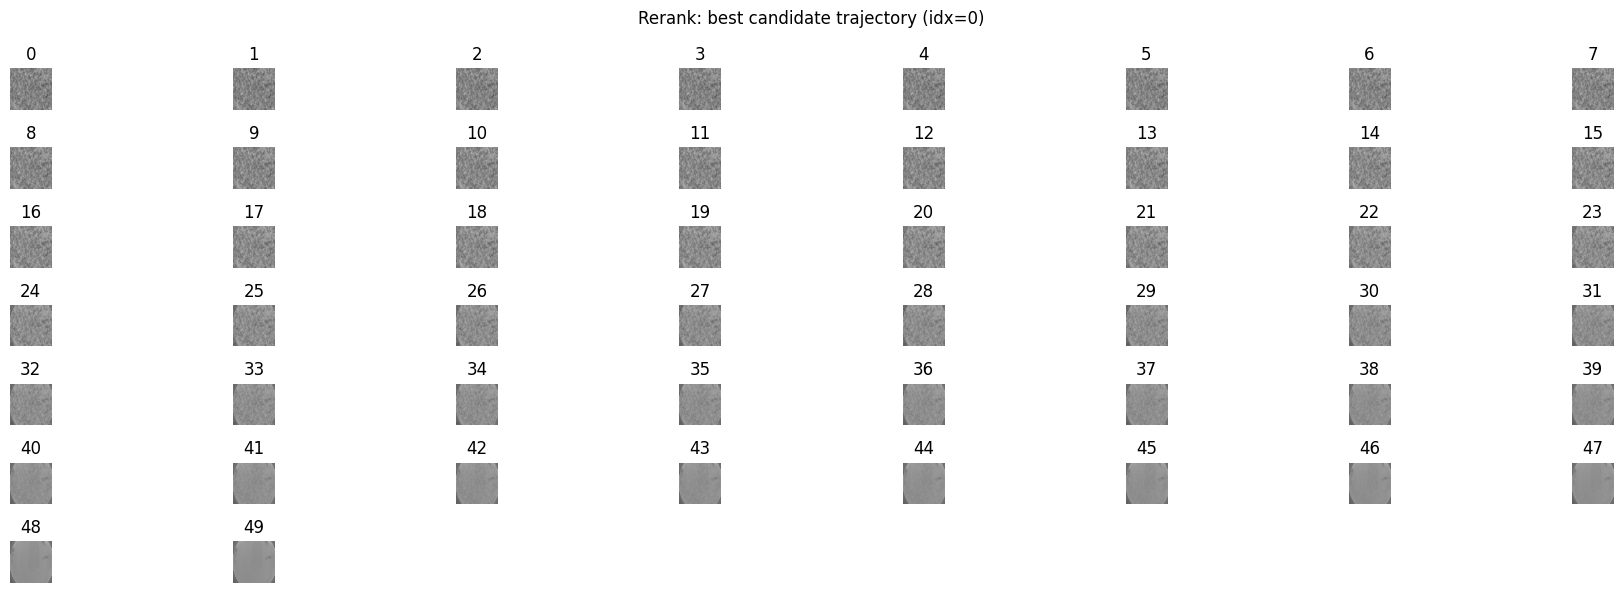

In [14]:
def run_rerank(
    pipe,
    guidance,
    steps: int,
    n_candidates: int = 8,
    batch_size: int = 1,
    store_every: int = 1,
):
    assert guidance is not None, "rerank needs guidance for scoring"

    cand_finals = []
    cand_energy = []
    cand_frames = []

    for c in range(n_candidates):
        frames, _ = run_euler_trajectory(
            pipe=pipe,
            steps=steps,
            batch_size=batch_size,
            guidance=None,
            guidance_scale=0.0,
            store_every=store_every,
            score_every=None,
        )
        # Re-run once to get final z for scoring (cheap compared to storing z-history in this helper)
        # If you want exact z from the stored run, extend run_euler_trajectory to also return final z.
        shape = pipe._get_unet_sample_shape()
        z = torch.randn(batch_size, *shape, device=pipe.device)
        dt = 1.0 / steps
        for i in range(steps):
            t_val = i / steps
            t = torch.full((batch_size,), t_val, device=pipe.device)
            with torch.no_grad():
                unet_out = pipe.unet(z, t * pipe.t_scale).sample
                if pipe.train_target == "x0":
                    t_exp = t[:, None, None, None]
                    v = (unet_out - z) / (1.0 - t_exp).clamp(min=1e-5)
                else:
                    v = unet_out
            z = (z + v * dt).detach()

        with torch.no_grad():
            E = guidance.energy(z, pipeline=pipe)  # (B,)
            e = float(E.mean().item())

        cand_frames.append(frames)
        cand_finals.append(frames[-1])
        cand_energy.append(e)

    best = int(np.argmin(cand_energy))
    return best, cand_energy, cand_finals, cand_frames[best]

if guidance is None:
    print("No guidance => cannot run rerank.")
else:
    N_CAND = 8
    best_idx, energies, final_imgs, best_frames = run_rerank(
        pipe=pipe,
        guidance=guidance,
        steps=N_STEPS,
        n_candidates=N_CAND,
        batch_size=1,
        store_every=STORE_EVERY,
    )

    print("Candidate energies:", energies)
    print("Best candidate:", best_idx, "E=", energies[best_idx])

    show_grid(final_imgs, title="Rerank: final image of each candidate")
    show_grid(best_frames, title=f"Rerank: best candidate trajectory (idx={best_idx})")

beam: 100%|██████████| 50/50 [00:17<00:00,  2.91it/s]


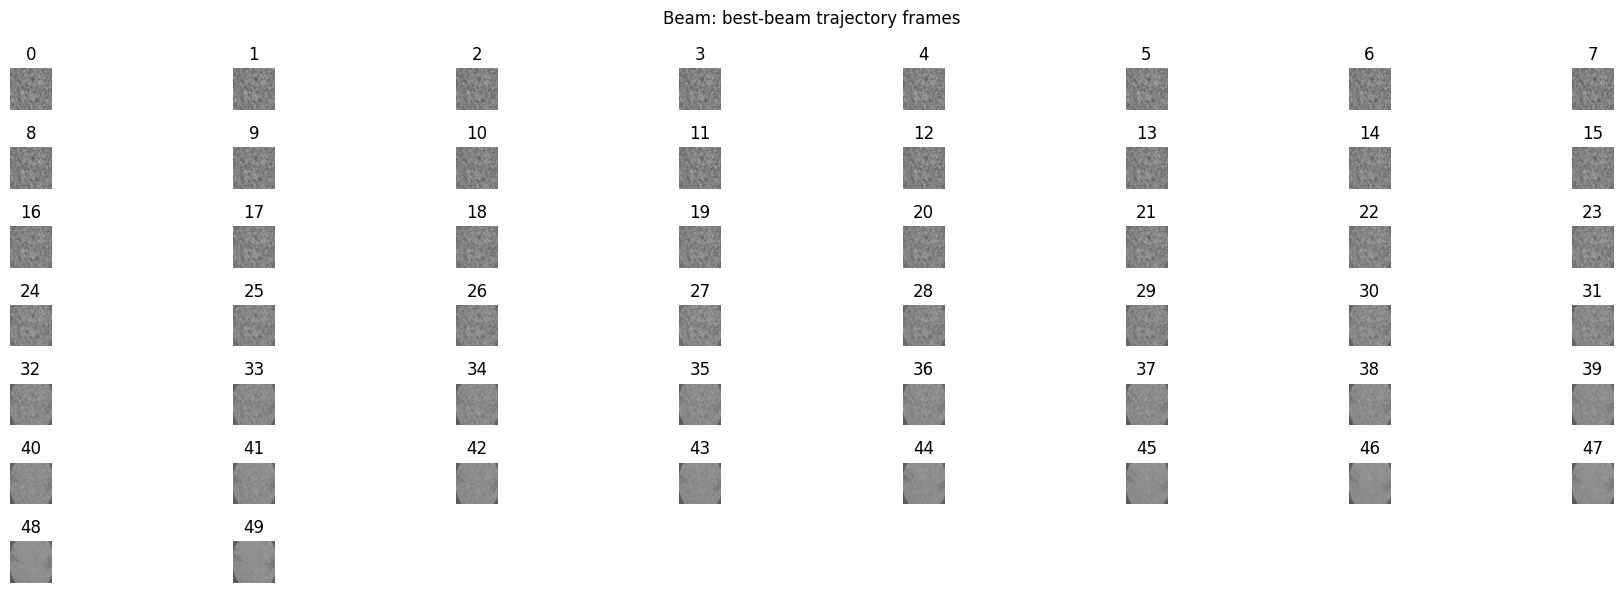

In [ ]:
def run_beam(
    pipe,
    guidance,
    steps: int,
    batch_size: int = 1,
    beam_size: int = 4,
    branch_factor: int = 2,
    sigma_perturb: float = 0.05,
    store_every: int = 1,
):
    assert guidance is not None, "beam needs guidance for pruning"

    shape = pipe._get_unet_sample_shape()
    C, H, W = shape
    dt = 1.0 / steps

    # (beam_size, B, C, H, W)
    z_beams = torch.randn(beam_size, batch_size, C, H, W, device=pipe.device)

    frames = []

    for i in tqdm(range(steps), desc="beam"):
        t_val = i / steps
        t = torch.full((batch_size,), t_val, device=pipe.device)

        expanded = []
        for b in range(beam_size):
            z_b = z_beams[b]
            for _ in range(branch_factor):
                z_child = z_b + sigma_perturb * torch.randn_like(z_b) if sigma_perturb > 0 else z_b.clone()

                with torch.no_grad():
                    unet_out = pipe.unet(z_child, t * pipe.t_scale).sample
                    if pipe.train_target == "x0":
                        t_exp = t[:, None, None, None]
                        v = (unet_out - z_child) / (1.0 - t_exp).clamp(min=1e-5)
                    else:
                        v = unet_out

                z_next = (z_child + v * dt).detach()
                expanded.append(z_next)

        # (K, B, C, H, W)
        z_exp = torch.stack(expanded, dim=0)
        K = z_exp.shape[0]

        # Score all: flatten to (K*B, C, H, W)
        z_flat = z_exp.view(K * batch_size, C, H, W)
        with torch.no_grad():
            E_flat = guidance.energy(z_flat, pipeline=pipe).view(K, batch_size)  # (K,B)

        order = E_flat.argsort(dim=0)  # ascending energy = better
        new_beams = []
        for b_new in range(min(beam_size, K)):
            idx = order[b_new]  # (B,)
            new_beams.append(z_exp[idx, torch.arange(batch_size)])
        z_beams = torch.stack(new_beams, dim=0)

        # store best beam (index 0 after pruning)
        if (i % store_every) == 0 or (i == steps - 1):
            imgs = decode_to_vis(pipe, z_beams[0])
            frames.append(imgs[0])

    return frames

if guidance is None:
    print("No guidance => cannot run beam.")
else:
    frames_beam = run_beam(
        pipe=pipe,
        guidance=guidance,
        steps=N_STEPS,
        batch_size=1,
        beam_size=4,
        branch_factor=2,
        sigma_perturb=0.05,
        store_every=STORE_EVERY,
    )
    show_grid(frames_beam, title="Beam: best-beam trajectory frames")

refine:  20%|██        | 2/10 [00:00<00:00, 17.23it/s]

refine: 100%|██████████| 10/10 [00:00<00:00, 17.45it/s]


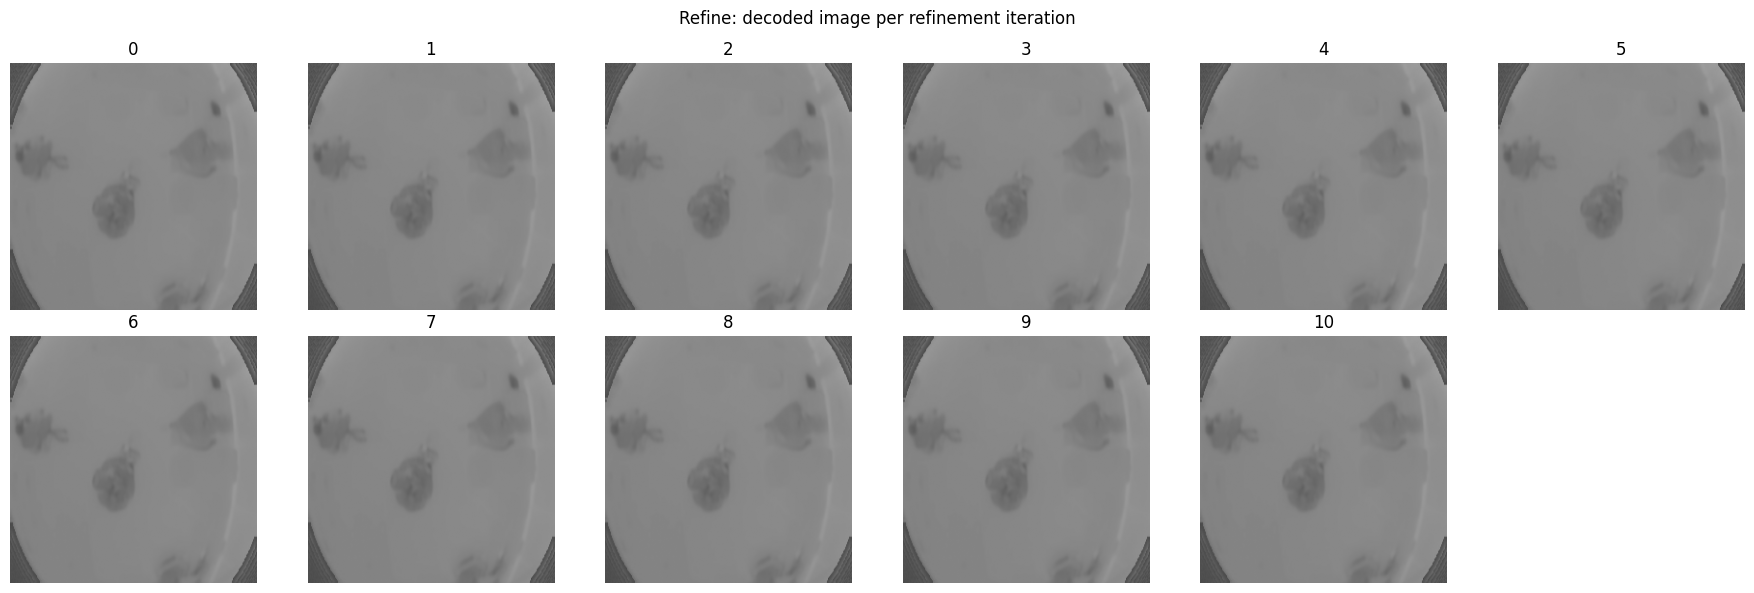

In [11]:
def sample_euler_final_z(pipe, steps: int, batch_size: int = 1):
    shape = pipe._get_unet_sample_shape()
    z = torch.randn(batch_size, *shape, device=pipe.device)
    dt = 1.0 / steps
    for i in range(steps):
        t_val = i / steps
        t = torch.full((batch_size,), t_val, device=pipe.device)
        with torch.no_grad():
            unet_out = pipe.unet(z, t * pipe.t_scale).sample
            if pipe.train_target == "x0":
                t_exp = t[:, None, None, None]
                v = (unet_out - z) / (1.0 - t_exp).clamp(min=1e-5)
            else:
                v = unet_out
        z = (z + v * dt).detach()
    return z

def refine_with_frames(pipe, z0, guidance, num_steps: int = 10, step_size: float = 0.01):
    assert guidance is not None
    z = z0.detach()
    frames = [decode_to_vis(pipe, z)[0]]
    for k in tqdm(range(num_steps), desc="refine"):
        g = guidance.guidance_grad(z, t=1.0, pipeline=pipe)
        z = (z + step_size * g).detach()
        frames.append(decode_to_vis(pipe, z)[0])
    return frames

if guidance is None:
    print("No guidance => cannot run refine.")
else:
    z0 = sample_euler_final_z(pipe, steps=N_STEPS, batch_size=1)
    frames_refine = refine_with_frames(pipe, z0, guidance, num_steps=10, step_size=0.01)
    show_grid(frames_refine, title="Refine: decoded image per refinement iteration", ncols=6)

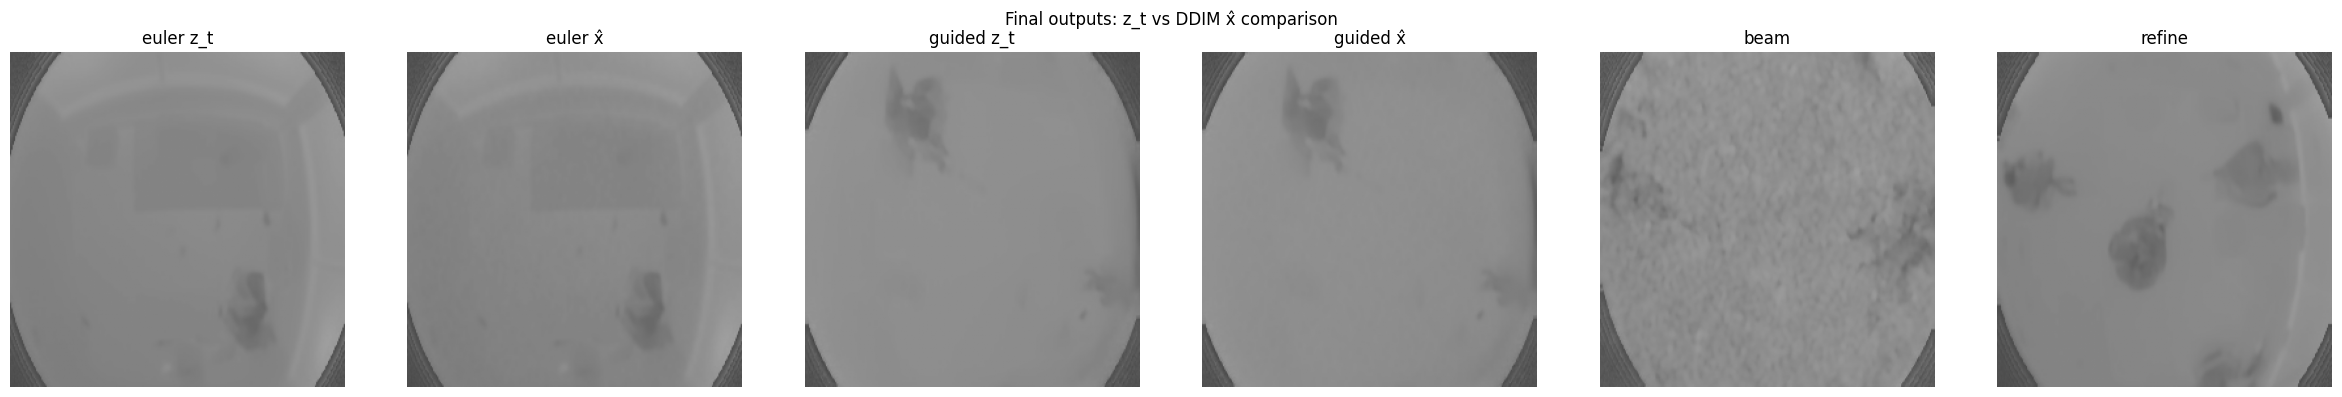

In [12]:
finals = {}

# Euler
finals["euler z_t"] = frames_euler[-1]
finals["euler x̂"]  = ddim_euler[-1]

# Euler guided
if guidance is not None:
    finals["guided z_t"] = frames_guided[-1]
    finals["guided x̂"]  = ddim_guided[-1]

# Beam
if guidance is not None and 'frames_beam' in dir():
    finals["beam"] = frames_beam[-1]

# Refine
if guidance is not None and 'frames_refine' in dir():
    finals["refine"] = frames_refine[-1]

# Display
imgs = [finals[k] for k in finals.keys()]
labels = list(finals.keys())

plt.figure(figsize=(4 * len(imgs), 4))
for i, (lab, img) in enumerate(zip(labels, imgs)):
    ax = plt.subplot(1, len(imgs), i + 1)
    ax.imshow(img, vmin=0, vmax=1, cmap="gray")
    ax.axis("off")
    ax.set_title(lab)
plt.suptitle("Final outputs: z_t vs DDIM x̂ comparison")
plt.tight_layout()
plt.show()